# Logistic Regression

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

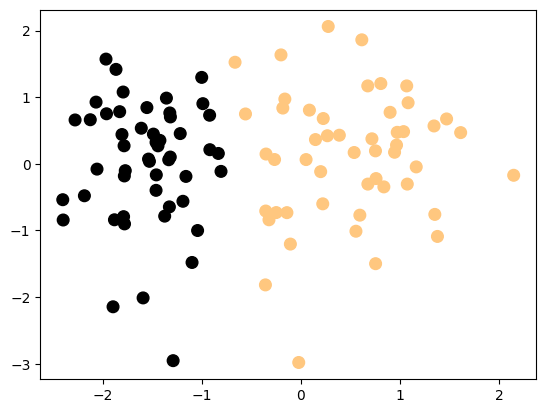

In [106]:
x,y = make_classification(n_samples = 100,
                          n_features=2,
                          n_redundant = 0,
                          n_clusters_per_class=1,
                          n_informative = 1,
                          n_classes = 2,
                          class_sep = 10,
                          hypercube = False,
                          random_state = 41)

plt.scatter(x[:,0], x[:,1], c = y, cmap = 'copper', s = 70)

## Logistic Regression - sklearn

In [107]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver = 'sag')
lr.fit(x,y)

print('intercept: ',lr.intercept_)
print('coef: ',lr.coef_)

intercept:  [2.25232213]
coef:  [[3.50228014 0.02839862]]


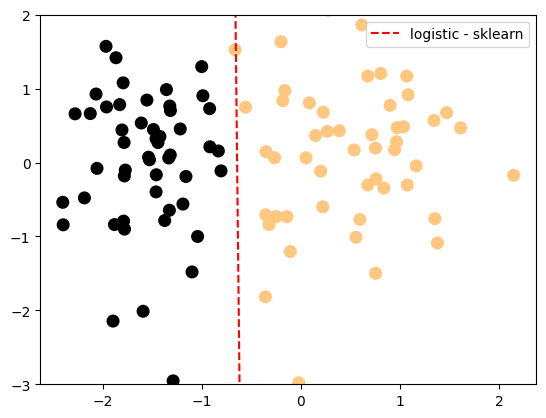

In [108]:
m1 = -lr.coef_[0][0] / lr.coef_[0][1]
b1 = -lr.intercept_ / lr.coef_[0][1]

x_input = np.linspace(-2,2, 100)
y_input = m1 * x_input + b1

plt.scatter(x[:,0], x[:,1], c = y, cmap = 'copper', s = 70)
plt.plot(x_input, y_input, color = 'red', ls = 'dashed', label = 'logistic - sklearn')
plt.legend()
plt.ylim(-3,2)
plt.show()

## Logistic Regression - GD function

In [109]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [110]:
def gradient_descent(x,y):
  n = 0.3
  epochs = 550
  x = np.insert(x,0,1,axis = 1)
  weights = np.ones(x.shape[1])

  for i in range(epochs):
    y_pred = sigmoid(np.dot(x,weights))
    weights = weights + (n * (np.dot((y - y_pred),x) / x.shape[0]))

  intercept = weights[0]
  coef = weights[1:]
  return intercept, coef

In [111]:
int, cof = gradient_descent(x,y)
print(int)
print(cof)

3.251543790345272
[5.19527235 0.09669572]


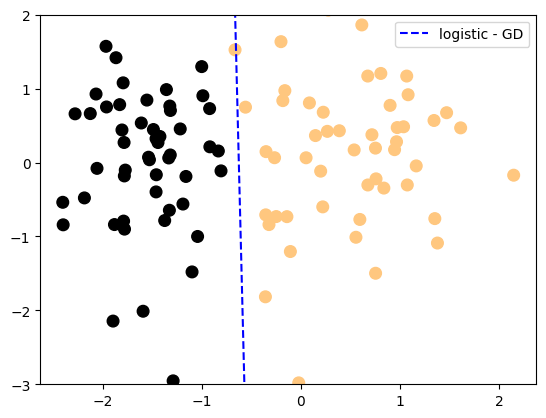

In [112]:
m2 = -cof[0] / cof[1]
b2 = -int / cof[1]

x_ip = np.linspace(-2,2, 100)
y_ip = m2 * x_ip + b2

plt.scatter(x[:,0], x[:,1], c = y, cmap = 'copper', s = 70)
plt.plot(x_ip, y_ip, color = 'blue', ls = 'dashed', label = 'logistic - GD')
plt.legend()
plt.ylim(-3,2)
plt.show()

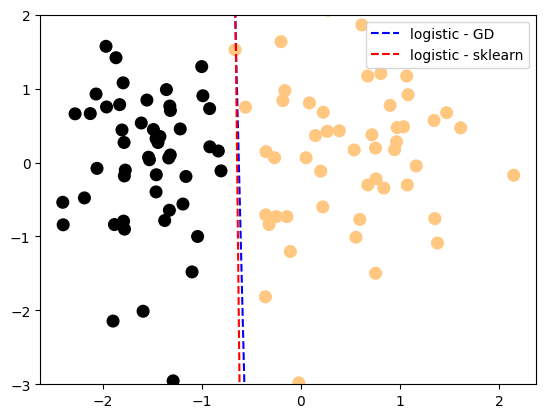

In [113]:
# comparison
plt.scatter(x[:,0], x[:,1], c = y, cmap = 'copper', s = 70)
plt.plot(x_ip, y_ip, color = 'blue', ls = 'dashed', label = 'logistic - GD')
plt.plot(x_input, y_input, color = 'red', ls = 'dashed', label = 'logistic - sklearn')
plt.legend()
plt.ylim(-3,2)
plt.show()